In [63]:
import numpy as np 
import matplotlib.pyplot as plt
import control as ctrl

# Info from Marks video

## VFD/Motor
* Min = 10 Hz
* Max = 70 Hz 


Unknown:
* Ramp time
* Nr of polepairs, i.e. Hz -> rpm

## CVT & Gearbox
* Gearbox high ratio 1:1 
* Gearbox low ratio 6.5:1
* CVT at highest setting & high ratio & 70 Hz -> 4200 rpm
* CVT at lowest setting & low ratio & 10 Hz -> 36 Hz
* 5 seconds to go from lowest to highest CVT setting
* CVT position to CVT ratio is nonlinear

Unknown:
* CVT positioning constant velocity?
* What type of nonlinearity is the CVT ratio?

# CVT
Given a VFD speed $f_{vfd}$, nr of polepairs $n_p$, gearbox ratio $k_{gear}$ and spindle rpm $n_{sp}$

$$
f_{vfd} \, n_p \, 60 \, k_{gear} k_{cvt} = n_{sp} 

$$

$$
k_{cvt} 
=
\frac{n_{sp}}{f_{vfd} \, n_p \, 60 \, k_{gear}}
$$



In [64]:

k_gear_high = 1.0
k_gear_low = 1/6.5 
n_p = 4


# CVT extreme gains
k_cvt_h = 4200/(70*n_p*60*k_gear_high)
k_cvt_l = 36/(10*n_p*60*k_gear_low)

print(f"Ratio CVT max:{k_cvt_h} Ratio CVT min:{k_cvt_l}")


Ratio CVT max:0.25 Ratio CVT min:0.0975


Assume we have a *CVT Position* $p_c$ that goes from 0 to 1. 0 is at its slowest position and 1 the highest.

Mark does no mention how the ratio depends on the position, only that it's nonlinear and takes 5 seconds to go from $p_c = 0$ to $p_c = 1$.

I will make two assumptions, its quadratic, i.e.

$$
k_{cvt} = a_2 p_c^2 + a_0
$$

and that the positioning motor of $p_c$ follows a PT1 filter with time constant $\tau_c$ and a integrator. The input to the filter $u_c$ depends on the value of the CVT control signals.
I.e. 

```python
u_c = 0

if cvt_cmd_high and not cvt_cmd_low:
    u_c = 1

if not cvt_cmd_high and cvt_cmd_low:
    u_c = -1
```

$$
p_c = \frac{1}{s} \frac{1}{s \tau_c + 1} u_c
$$






Text(0.5, 1.0, 'CVT gain as a function of CVT position')

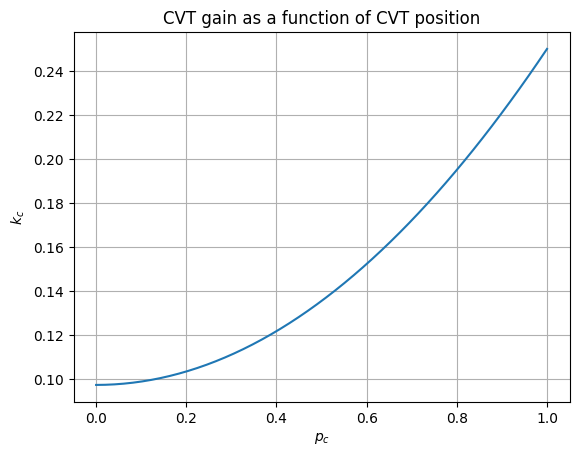

In [65]:
# Quadratic function
a_0 = k_cvt_l
a_2 = (k_cvt_h - k_cvt_l)

p_c = np.linspace(0,1)
k_cvt = a_0 + p_c**2 * a_2

plt.plot(p_c,k_cvt)
plt.xlabel("$p_c$")
plt.ylabel("$k_c$")
plt.grid(True)
plt.title("CVT gain as a function of CVT position")

In [66]:
cvt_tau_s = 0.3

v_cvt = 1/5


s = ctrl.tf('s')
G_cvt_p = 1/(cvt_tau_s*s + 1)
G_cvt_p

TransferFunction(array([1]), array([0.3, 1. ]))

1.0


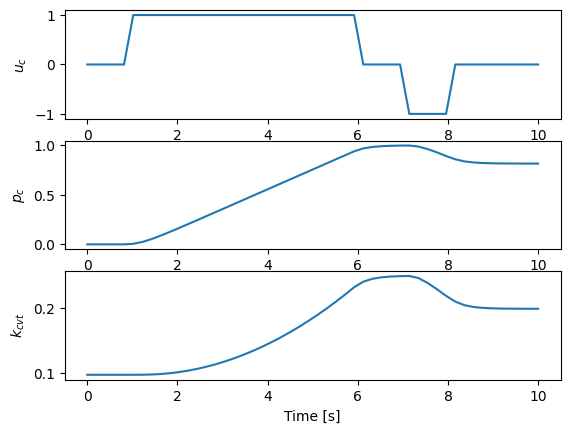

In [67]:
t = np.linspace(0,10)

u_c = np.zeros(t.shape)

indx_high = (t > 1) & (t < 6)
indx_low = (t > 7) & (t < 8)

u_c[indx_high] = 1
u_c[indx_low] = -1

# Cmd to unlimited pos
_,p_c = ctrl.forced_response(v_cvt/s,T=t,U=u_c)

# limit pos
p_c = np.clip(p_c,0,1)

# Filter for smooth traj
_,p_cf = ctrl.forced_response(G_cvt_p,T=t,U=p_c)


plt.subplot(3,1,1)
plt.plot(t,u_c)
plt.ylabel('$u_c$')

plt.subplot(3,1,2)
plt.plot(t,p_cf)
plt.ylabel('$p_c$')

plt.subplot(3,1,3)
plt.plot(t,a_0 + p_cf**2 * a_2)
plt.ylabel('$k_{cvt}$')

plt.xlabel('Time [s]')

print(np.max(p_c))

# Speed ranges

Text(0, 0.5, 'Spindle speed')

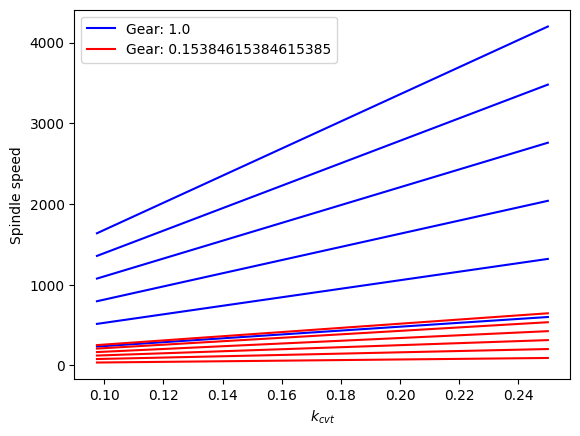

In [68]:
f_vfd = np.linspace(10,70,6)
#f_vfd = np.linspace(30,60,6)
k_cvt2 = np.linspace(k_cvt_l,k_cvt_h)
k_gearbox = [1.0,1/6.5]
k_colors = ['b','r']


for kg, color in zip(k_gearbox, k_colors):
    for i, f in enumerate(f_vfd):
        n = f * n_p * 60 * kg * k_cvt2
        label = f'Gear: {kg}' if i == 0 else '_nolegend_'
        plt.plot(k_cvt2, n, color=color, label=label)

plt.legend()
plt.xlabel('$k_{cvt}$')
plt.ylabel('Spindle speed')


Text(0, 0.5, 'Spindle speed')

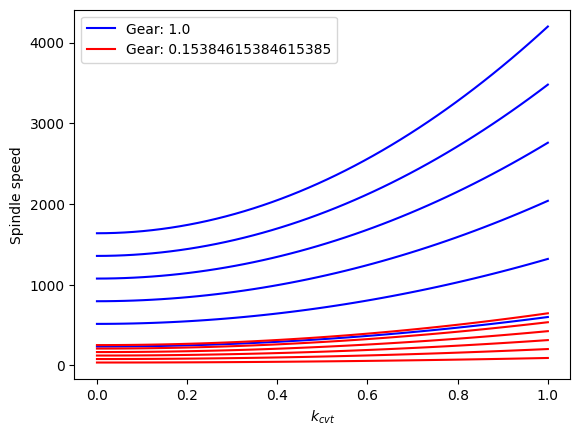

In [69]:
f_vfd = np.linspace(10,70,6)
#f_vfd = np.linspace(30,60,6)
k_gearbox = [1.0,1/6.5]
k_colors = ['b','r']
p_c = np.linspace(0,1)

for kg, color in zip(k_gearbox, k_colors):
    for i, f in enumerate(f_vfd):
        n = f * n_p * 60 * kg * k_cvt
        label = f'Gear: {kg}' if i == 0 else '_nolegend_'
        plt.plot(p_c, n, color=color, label=label)

plt.legend()
plt.xlabel('$k_{cvt}$')
plt.ylabel('Spindle speed')

Text(0, 0.5, 'Spindle speed')

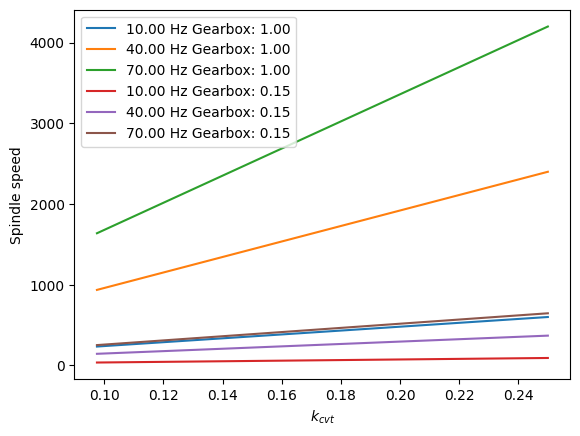

In [70]:
f_vfd = np.linspace(10,70,3)
#f_vfd = np.linspace(30,60,6)
k_cvt2 = np.linspace(k_cvt_l,k_cvt_h)
k_gearbox = [1.0,1/6.5]



for kg in k_gearbox:
    for i, f in enumerate(f_vfd):
        n = f * n_p * 60 * kg * k_cvt2
        #label = f'Gear: {kg}' #if i == 0 else '_nolegend_'
        label = f'{f:.2f} Hz Gearbox: {kg:.2f}'
        plt.plot(k_cvt2, n, label=label)

plt.legend()
plt.xlabel('$k_{cvt}$')
plt.ylabel('Spindle speed')


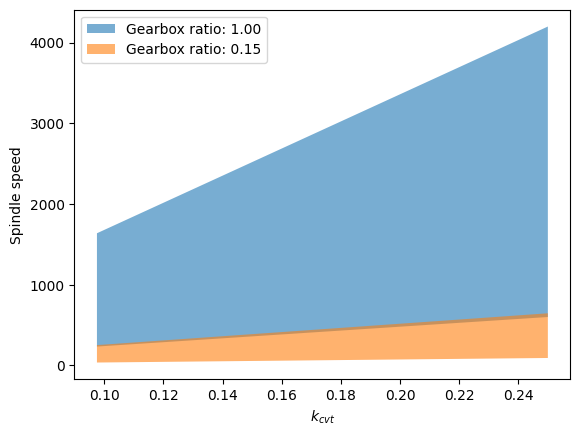

In [71]:
f_vfd = np.linspace(10,70,3)
#f_vfd = np.linspace(30,60,6)
k_cvt2 = np.linspace(k_cvt_l,k_cvt_h)
k_gearbox = [1.0,1/6.5]

for kg in k_gearbox:

    # Max freq
    n70h =  70 * n_p * 60 * kg * k_cvt_h
    n10h =  10 * n_p * 60 * kg * k_cvt_h

    n70l =  70 * n_p * 60 * kg * k_cvt_l
    n10l =  10 * n_p * 60 * kg * k_cvt_l

    plt.fill_between([k_cvt_l,k_cvt_h],[n10l,n10h],[n70l,n70h],label=f'Gearbox ratio: {kg:.2f}',alpha=0.6)

plt.legend()
plt.xlabel('$k_{cvt}$')
plt.ylabel('Spindle speed')
plt.savefig('docs/sp_range_gears.png')

# Optimal operating point

Here some ideas for the ideal operating point will be discussed

## Ideal operation curve

Mark mentioned that the ideal operation is to run the VFD at 50 Hz. Thus we can stick to that line and only deviate at the extreme endpoints.



234.0 4200.0


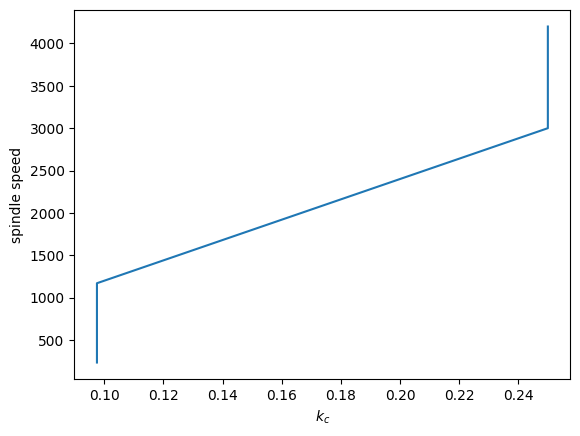

In [72]:


n_setpoints = np.linspace(400,4200)


#n = f * n_p * 60 * kg * k_cvt2


f_op_max = 50
f_op_min = 50
f_max = 70
f_min = 10

kg = 1

# upper limit with f = 50
n_upper = f_op_max * n_p * 60 * kg * k_cvt_h
n_lower = f_op_min * n_p * 60 * kg * k_cvt_l

n_max = f_max * n_p * 60 * kg * k_cvt_h
n_min = f_min * n_p * 60 * kg * k_cvt_l


plt.plot([k_cvt_l,k_cvt_l,k_cvt_h,k_cvt_h],[n_min, n_lower, n_upper, n_max])
plt.xlabel('$k_c$')
plt.ylabel('spindle speed')

print(n_min,n_max)

Check inverse function

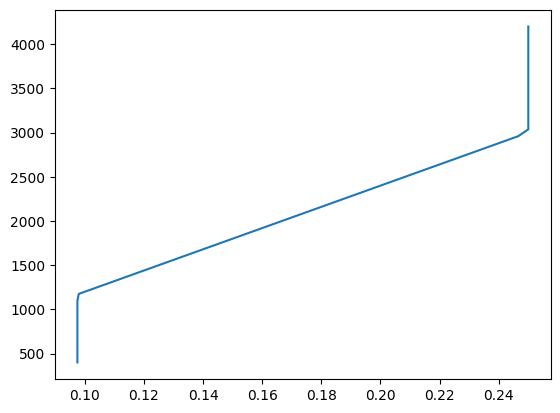

In [73]:

def calc_op_point(sp_setpoint):

    f_op_max = 50
    f_op_min = 50
    f_max = 70
    f_min = 10

    kg = 1
    n_p = 4

    # upper limit with f = 50
    n_upper = f_op_max * n_p * 60 * kg * k_cvt_h
    n_lower = f_op_min * n_p * 60 * kg * k_cvt_l

    n_max = f_max * n_p * 60 * kg * k_cvt_h
    n_min = f_min * n_p * 60 * kg * k_cvt_l

    kc = 0.17
    f = 0

    # Limit values of sp setpoint
    sp_setpoint = np.clip(sp_setpoint,0.0,n_max)

    if sp_setpoint > n_upper:
        kc = k_cvt_h
        f = sp_setpoint/(n_p*60*kg*kc)
    elif sp_setpoint > n_lower:
        f = 50
        kc = sp_setpoint/(n_p*60*kg*f)
    elif sp_setpoint > n_min:
        kc = k_cvt_l
        f = sp_setpoint/(n_p*60*kg*kc)
    else:
        f = 0.0

    return f,kc

k_cs = []

for ssp in n_setpoints:
    _,k = calc_op_point(ssp)
    k_cs.append(k)

plt.plot(k_cs,n_setpoints)



## Numerical optimization
Another approach is to solve an actual optimization problem online.

Given the decision variables $f$ and $k_c$ it should be possible to solve the optimization problem

$$
\min_{f,k_c} q_f(50 - f)^2 + (0.17 - k_c)^2 \\
\text{s.t.} \\
n_s = k_{gearbox} \, k_c \, n_p \, 60 \, f \\
0.0975 \leq k_c \leq 0.25
$$

I will rewrite it using $f^* = \frac{n_s}{f}$


This results in

$$
\min_{f^*,k_c} q_f(\frac{n_s}{50} - f^*)^2 + (0.17 - k_c)^2 \\
\text{s.t.} \\
f^* = k_{gearbox} \, k_c \, n_p \, 60 \\
0.0975 \leq k_c \leq 0.25
$$

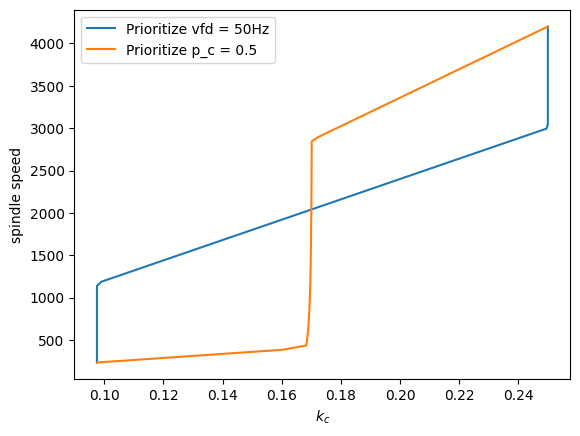

In [74]:
# Using scipy opt for the concept, but should be possible to solve analytically using KKT
from scipy import optimize


def find_opt_settings(sp_setpoint:float, qf=1.0):

    # Cost
    def J(z):
        fs,kc = z 
        #qf = 0.001
        return qf*(sp_setpoint/50 - fs)**2 + sp_setpoint*(0.17 - kc)**2
    
    def eq_constraint(z):
        fs,kc = z 
        return (fs - kc*n_p*60)*10
    
    cons = [{'type': 'eq', 'fun': eq_constraint}]
    z0 = (sp_setpoint/50, 0.17)
    bounds = [(sp_setpoint/70, sp_setpoint/10), (0.0975,0.25)]

    sol = optimize.minimize(J,x0=z0,bounds=bounds, constraints=cons)
    fs,kc = sol.x 
    #print(sol)
    f = sp_setpoint/fs
    return f,kc


sp_setpoints = np.linspace(n_min,n_max,80)
k_cs = []

for ssp in sp_setpoints:
    _,k = find_opt_settings(ssp,qf=100)
    k_cs.append(k)

plt.plot(k_cs,sp_setpoints,label='Prioritize vfd = 50Hz')


k_cs = []

for ssp in sp_setpoints:
    _,k = find_opt_settings(ssp,qf=1e-4)
    k_cs.append(k)

plt.plot(k_cs,sp_setpoints,label='Prioritize p_c = 0.5')
plt.legend()
plt.xlabel('$k_c$')
plt.ylabel('spindle speed')
plt.savefig('docs/operating_curves.png')

This shows the ideal curves if you want to keep the VFD frequencey at 50 Hz or the CVT position in the middle ($k_c = 0.17$)